# 🥇 03 — Gold Layer (Silver → Gold)

**Pipeline:** IBM Cloud Object Storage · Medallion Architecture  
**Autor:** Federico Pfund  
**Fecha:** Abril 2026  

---

## Objetivo

Construir el **Star Schema** de consumo para BI a partir de las tablas Silver.  
Formato de persistencia: **Parquet** en bucket `datalake-gold-us-south`.

### Modelo Dimensional

```
                    ┌─────────────────┐
                    │  dim_producto  │
                    └───────┬─────────┘
                            │
┌───────────────┐   ┌─────┫─────────┐   ┌──────────────────────┐
│  dim_cliente  │───│  fact_ventas  │───│  kpi_ventas_mensuales   │
└───────────────┘   └───────────────┘   └──────────────────────┘

┌───────────────┐   ┌─────────────────────┐   ┌───────────────┐
│ dim_operador  │───│ fact_produccion_minera │───│  kpi_mineria   │
└───────────────┘   └─────────────────────┘   └───────────────┘
```

### Tablas de Salida

| # | Tabla Gold | Tipo | Fuentes Silver | Dominio |
|---|-----------|------|----------------|----------|
| 1 | `dim_producto` | Dimension | catalogo_productos + rentabilidad_producto | Retail |
| 2 | `dim_cliente` | Dimension | segmentacion_clientes | Retail |
| 3 | `dim_tiempo` | Dimension | ventas_enriquecidas (generada) | Retail |
| 4 | `dim_operador` | Dimension | produccion_operador | Mineria |
| 5 | `fact_ventas` | Fact | ventas_enriquecidas + dims | Retail |
| 6 | `fact_produccion_minera` | Fact | eficiencia_minera + dims | Mineria |
| 7 | `kpi_ventas_mensuales` | KPI | resumen_ventas_mensuales | Retail |
| 8 | `kpi_mineria` | KPI | eficiencia_minera + produccion_por_pais | Mineria |

---
## 1. Inicializacion del Entorno Spark

In [1]:
# ============================================================================
# INICIALIZACION: SparkSession + dependencias
# ----------------------------------------------------------------------------
# - Carga config.py con credenciales COS, Db2 JDBC y builder de Spark.
# - Paquetes Maven: hadoop-aws (S3A), aws-java-sdk, db2 jcc, delta-core.
# - Librerias de visualizacion: matplotlib + seaborn.
# ============================================================================
import sys, os, warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from config import build_spark, cos_path

from pyspark.sql import functions as F
from pyspark.sql.window import Window
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# -- Estilo global de graficos --
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120

# -- Crear sesion Spark --
spark = build_spark('Gold-Layer')
print(f'SparkSession activa | Version: {spark.version}')
print(f'   App Name   : {spark.sparkContext.appName}')
print(f'   Master     : {spark.sparkContext.master}')
print(f'   Executors  : {spark.sparkContext.defaultParallelism}')

26/04/12 21:40:52 WARN Utils: Your hostname, codespaces-a19825 resolves to a loopback address: 127.0.0.1; using 10.0.0.67 instead (on interface eth0)
26/04/12 21:40:52 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


:: loading settings :: url = jar:file:/workspaces/data-engineer/.venv/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/codespace/.ivy2/cache
The jars for the packages stored in: /home/codespace/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
com.amazonaws#aws-java-sdk-bundle added as a dependency
com.ibm.db2#jcc added as a dependency
io.delta#delta-core_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-562b97e9-b3bb-49aa-9663-c7244847ea67;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
	found com.ibm.db2#jcc;11.5.9.0 in central
	found io.delta#delta-core_2.12;2.3.0 in central
	found io.delta#delta-storage;2.3.0 in central
	found org.antlr#antlr4-runtime;4.8 in central
:: resolution report :: resolve 734ms :: artifacts dl 51ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.262 from central in [default]
	com.ibm.db2#jcc;11.5.9.0 from central in [default

SparkSession activa | Version: 3.5.4
   App Name   : Gold-Layer
   Master     : local[*]
   Executors  : 2


---
## 2. Carga de Tablas Silver

Se leen las 8 tablas del bucket **Silver** en formato Parquet.  
Se valida el conteo de cada tabla para confirmar integridad post-transformacion.

In [2]:
# ============================================================================
# CARGA SILVER: Lectura de todas las tablas Parquet desde COS Silver
# ============================================================================
SILVER_TABLE_NAMES = [
    'catalogo_productos', 'ventas_enriquecidas', 'resumen_ventas_mensuales',
    'rentabilidad_producto', 'segmentacion_clientes',
    'produccion_operador', 'eficiencia_minera', 'produccion_por_pais',
]

silver = {}
load_stats = []

for t in SILVER_TABLE_NAMES:
    silver[t] = spark.read.parquet(cos_path('silver', t))
    row_count = silver[t].count()
    col_count = len(silver[t].columns)
    load_stats.append({'Tabla': t, 'Filas': row_count, 'Columnas': col_count})
    print(f'  Loaded silver/{t}: {row_count:,} filas x {col_count} cols')

df_load = pd.DataFrame(load_stats)
total_silver_rows = df_load['Filas'].sum()
print(f'\n{len(silver)} tablas Silver cargadas | Total: {total_silver_rows:,} registros')
display(df_load)

26/04/12 21:41:38 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties


  Loaded silver/catalogo_productos: 319 filas x 5 cols


  Loaded silver/ventas_enriquecidas: 47,263 filas x 28 cols
  Loaded silver/resumen_ventas_mensuales: 65 filas x 10 cols


  Loaded silver/rentabilidad_producto: 147 filas x 10 cols
  Loaded silver/segmentacion_clientes: 17,555 filas x 15 cols
  Loaded silver/produccion_operador: 9,132 filas x 11 cols
  Loaded silver/eficiencia_minera: 7 filas x 8 cols
  Loaded silver/produccion_por_pais: 6 filas x 8 cols

8 tablas Silver cargadas | Total: 74,494 registros


,Tabla,Filas,Columnas
0,catalogo_productos,319,5
1,ventas_enriquecidas,47263,28
2,resumen_ventas_mensuales,65,10
3,rentabilidad_producto,147,10
4,segmentacion_clientes,17555,15
5,produccion_operador,9132,11
6,eficiencia_minera,7,8
7,produccion_por_pais,6,8


---
## 3. Dimension: Producto

**Fuentes:** `catalogo_productos` + `rentabilidad_producto`

Enriquecimiento del catalogo con metricas de negocio:

| Campo Calculado | Logica |
|-----------------|--------|
| `Clasificacion_Rentabilidad` | Estrella (>=60%) / Rentable (>=40%) / Standard (>=20%) / Bajo Margen (>0%) / Sin Ventas |
| `Rotacion` | Alta (>=500) / Media (>=100) / Baja (>0) / Sin Movimiento |
| `producto_key` | Surrogate key (monotonically_increasing_id) |

In [3]:
# ============================================================================
# DIM_PRODUCTO: Catalogo enriquecido con clasificaciones de negocio
# ----------------------------------------------------------------------------
# Join: catalogo_productos + rentabilidad_producto
# Output: producto_key, Cod_Producto, Producto, Color, SubCategoria,
#         Categoria, Veces_Vendido, Revenue_Total, Pct_Margen_Promedio,
#         Clasificacion_Rentabilidad, Rotacion
# ============================================================================
t0 = datetime.now()

dim_producto = (
    silver['catalogo_productos']
    .join(
        silver['rentabilidad_producto'].select(
            'Cod_Producto', 'Veces_Vendido', 'Revenue_Total',
            'Pct_Margen_Promedio', 'Precio_Promedio'
        ),
        'Cod_Producto', 'left'
    )
    .withColumn('producto_key', F.monotonically_increasing_id())
    .withColumn('Clasificacion_Rentabilidad',
        F.when(F.col('Pct_Margen_Promedio') >= 60, 'Estrella')
         .when(F.col('Pct_Margen_Promedio') >= 40, 'Rentable')
         .when(F.col('Pct_Margen_Promedio') >= 20, 'Standard')
         .when(F.col('Pct_Margen_Promedio') > 0, 'Bajo Margen')
         .otherwise('Sin Ventas'))
    .withColumn('Rotacion',
        F.when(F.coalesce(F.col('Veces_Vendido'), F.lit(0)) >= 500, 'Alta Rotacion')
         .when(F.coalesce(F.col('Veces_Vendido'), F.lit(0)) >= 100, 'Media Rotacion')
         .when(F.coalesce(F.col('Veces_Vendido'), F.lit(0)) > 0, 'Baja Rotacion')
         .otherwise('Sin Movimiento'))
)

dim_producto.write.mode('overwrite').parquet(cos_path('gold', 'dim_producto'))
dim_prod_count = dim_producto.count()
elapsed = (datetime.now() - t0).total_seconds()

print(f'dim_producto: {dim_prod_count:,} filas | {elapsed:.1f}s')
print(f'   Clasificaciones: {dim_producto.groupBy("Clasificacion_Rentabilidad").count().collect()}')
print(f'   Rotaciones: {dim_producto.groupBy("Rotacion").count().collect()}')

dim_producto.show(10, truncate=30)

dim_producto: 319 filas | 9.0s


   Clasificaciones: [Row(Clasificacion_Rentabilidad='Rentable', count=46), Row(Clasificacion_Rentabilidad='Estrella', count=23), Row(Clasificacion_Rentabilidad='Standard', count=78), Row(Clasificacion_Rentabilidad='Sin Ventas', count=172)]
   Rotaciones: [Row(Rotacion='Media Rotacion', count=70), Row(Rotacion='Baja Rotacion', count=60), Row(Rotacion='Alta Rotacion', count=17), Row(Rotacion='Sin Movimiento', count=172)]
+------------+------------------------------+-----+------------+---------+-------------+-------------+-------------------+---------------+------------+--------------------------+--------------+
|Cod_Producto|                      Producto|Color|SubCategoria|Categoria|Veces_Vendido|Revenue_Total|Pct_Margen_Promedio|Precio_Promedio|producto_key|Clasificacion_Rentabilidad|      Rotacion|
+------------+------------------------------+-----+------------+---------+-------------+-------------+-------------------+---------------+------------+--------------------------+-----------

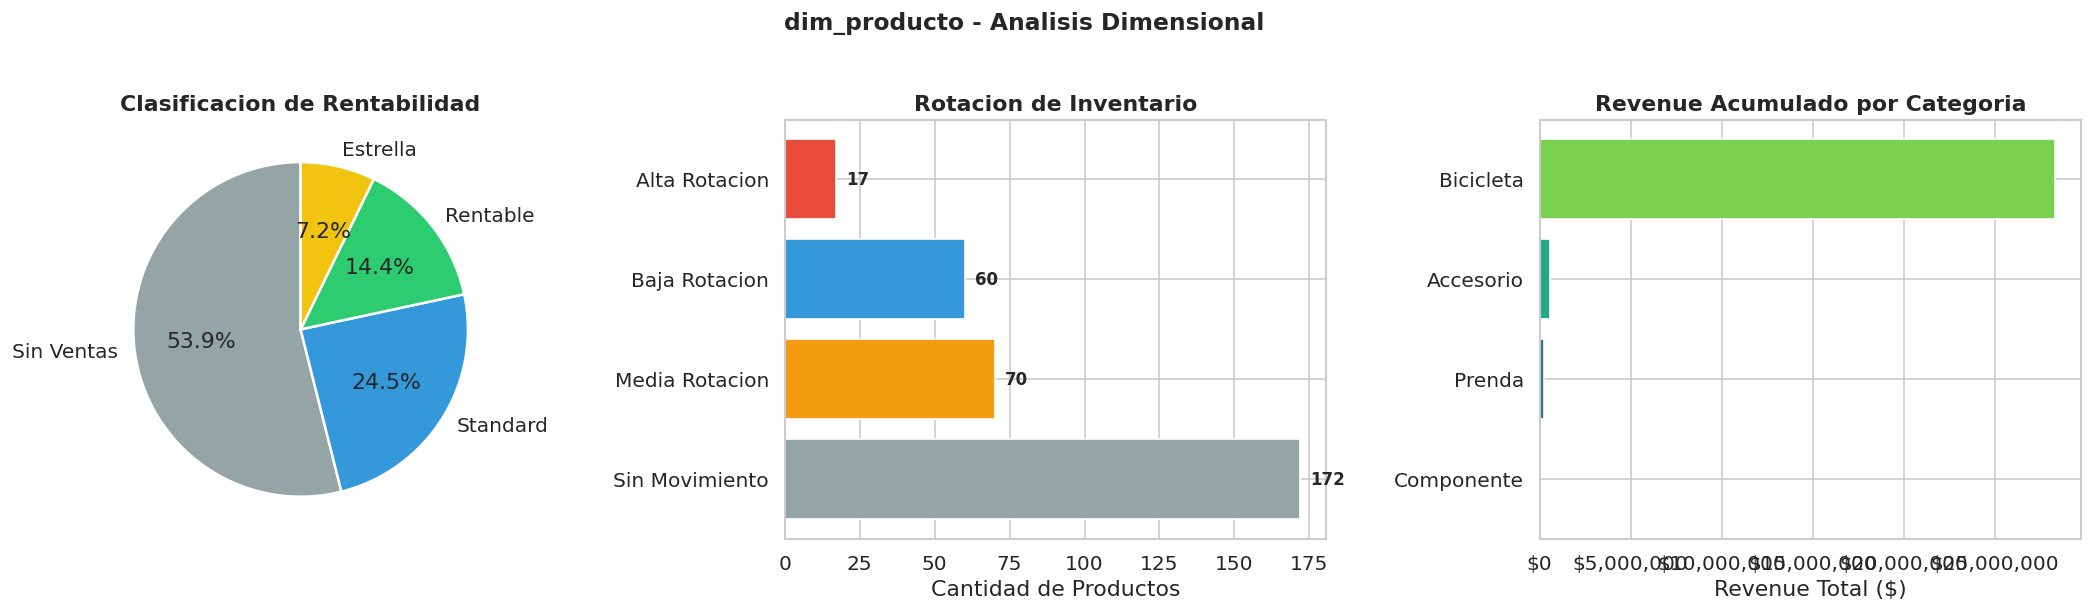

In [4]:
# ============================================================================
# GRAFICO: Distribucion de dim_producto por clasificacion y rotacion
# ============================================================================
df_prod_pd = dim_producto.select(
    'Categoria', 'Clasificacion_Rentabilidad', 'Rotacion',
    'Revenue_Total', 'Pct_Margen_Promedio'
).toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -- Panel 1: Clasificacion de Rentabilidad --
rent_counts = df_prod_pd['Clasificacion_Rentabilidad'].value_counts()
colors_rent = {
    'Estrella': '#f1c40f', 'Rentable': '#2ecc71', 'Standard': '#3498db',
    'Bajo Margen': '#e67e22', 'Sin Ventas': '#95a5a6'
}
axes[0].pie(rent_counts.values, labels=rent_counts.index, autopct='%1.1f%%',
            colors=[colors_rent.get(s, '#bdc3c7') for s in rent_counts.index],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title('Clasificacion de Rentabilidad', fontweight='bold')

# -- Panel 2: Rotacion de productos --
rot_counts = df_prod_pd['Rotacion'].value_counts()
colors_rot = {
    'Alta Rotacion': '#e74c3c', 'Media Rotacion': '#f39c12',
    'Baja Rotacion': '#3498db', 'Sin Movimiento': '#95a5a6'
}
bars = axes[1].barh(rot_counts.index, rot_counts.values,
                    color=[colors_rot.get(r, '#bdc3c7') for r in rot_counts.index],
                    edgecolor='white')
axes[1].set_xlabel('Cantidad de Productos')
axes[1].set_title('Rotacion de Inventario', fontweight='bold')
for bar, val in zip(bars, rot_counts.values):
    axes[1].text(bar.get_width() + rot_counts.max() * 0.02,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val}', va='center', fontsize=10, fontweight='bold')

# -- Panel 3: Revenue por categoria --
cat_rev = df_prod_pd.groupby('Categoria')['Revenue_Total'].sum().dropna().sort_values()
colors_cat = sns.color_palette('viridis', len(cat_rev))
axes[2].barh(cat_rev.index, cat_rev.values, color=colors_cat, edgecolor='white')
axes[2].set_xlabel('Revenue Total ($)')
axes[2].set_title('Revenue Acumulado por Categoria', fontweight='bold')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('dim_producto - Analisis Dimensional',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Dimension: Cliente

**Fuente:** `segmentacion_clientes`

Dimension de clientes con segmentacion RFM precalculada, LTV anualizado y scoring.

| Campo | Descripcion |
|-------|-------------|
| `cliente_key` | Surrogate key |
| `Segmento` | VIP / Frecuente / Regular / En Riesgo |
| `LTV_Anualizado` | Lifetime Value proyectado a 365 dias |
| `Rango_LTV` | Premium / Alto / Medio / Basico (clasificacion por cuartiles) |

In [5]:
# ============================================================================
# DIM_CLIENTE: Dimension con segmentacion RFM + LTV + clasificaciones
# ============================================================================
t0 = datetime.now()

# Calcular percentiles de LTV para clasificacion
ltv_quantiles = silver['segmentacion_clientes'].approxQuantile(
    'LTV_Anualizado', [0.25, 0.50, 0.75], 0.01
)
q1, q2, q3 = ltv_quantiles
print(f'LTV Cuartiles: Q1={q1:,.0f} | Q2={q2:,.0f} | Q3={q3:,.0f}')

dim_cliente = (
    silver['segmentacion_clientes']
    .withColumn('cliente_key', F.monotonically_increasing_id())
    .withColumn('Rango_LTV',
        F.when(F.col('LTV_Anualizado') >= q3, 'Premium')
         .when(F.col('LTV_Anualizado') >= q2, 'Alto')
         .when(F.col('LTV_Anualizado') >= q1, 'Medio')
         .otherwise('Basico'))
    .select(
        'cliente_key', 'Cod_Cliente', 'Recency', 'Frecuencia', 'Monetary',
        'Ticket_Promedio', 'Ganancia_Neta_Total', 'Productos_Distintos',
        'Dias_Como_Cliente', 'LTV_Anualizado', 'Segmento', 'Rango_LTV',
        'score_recency', 'score_frecuencia', 'score_monetario',
    )
)

dim_cliente.write.mode('overwrite').parquet(cos_path('gold', 'dim_cliente'))
dim_cli_count = dim_cliente.count()
elapsed = (datetime.now() - t0).total_seconds()

print(f'\ndim_cliente: {dim_cli_count:,} filas | {elapsed:.1f}s')

# Resumen por segmento y rango LTV
print('\nDistribucion Segmento x Rango LTV:')
dim_cliente.groupBy('Segmento', 'Rango_LTV').count().orderBy('Segmento', 'Rango_LTV').show(20, truncate=False)

LTV Cuartiles: Q1=40 | Q2=575 | Q3=2,393



dim_cliente: 17,555 filas | 5.8s

Distribucion Segmento x Rango LTV:
+---------+---------+-----+
|Segmento |Rango_LTV|count|
+---------+---------+-----+
|En Riesgo|Alto     |1083 |
|En Riesgo|Basico   |1683 |
|En Riesgo|Medio    |1571 |
|En Riesgo|Premium  |638  |
|Frecuente|Alto     |1435 |
|Frecuente|Basico   |1384 |
|Frecuente|Medio    |2497 |
|Frecuente|Premium  |228  |
|Regular  |Alto     |442  |
|Regular  |Basico   |819  |
|Regular  |Medio    |719  |
|Regular  |Premium  |67   |
|VIP      |Alto     |1341 |
|VIP      |Medio    |18   |
|VIP      |Premium  |3630 |
+---------+---------+-----+



---
## 5. Dimension: Tiempo

**Generada** a partir del rango de fechas de `ventas_enriquecidas`.

Dimension de calendario para facilitar analisis temporal en BI:
Year, Month, Quarter, DayOfWeek, IsWeekend, MonthName, QuarterLabel.

In [6]:
# ============================================================================
# DIM_TIEMPO: Dimension calendario generada desde rango de ventas
# ============================================================================
t0 = datetime.now()

# Obtener rango de fechas
date_range = silver['ventas_enriquecidas'].agg(
    F.min('FechaOrden').alias('min_date'),
    F.max('FechaOrden').alias('max_date')
).collect()[0]

print(f'Rango de fechas: {date_range["min_date"]} a {date_range["max_date"]}')

dim_tiempo = (
    spark.sql(f"""
        SELECT explode(sequence(
            to_date('{date_range['min_date']}'),
            to_date('{date_range['max_date']}'),
            interval 1 day
        )) AS Fecha
    """)
    .withColumn('tiempo_key', F.date_format('Fecha', 'yyyyMMdd').cast('int'))
    .withColumn('Year', F.year('Fecha'))
    .withColumn('Month', F.month('Fecha'))
    .withColumn('Day', F.dayofmonth('Fecha'))
    .withColumn('Quarter', F.quarter('Fecha'))
    .withColumn('DayOfWeek', F.dayofweek('Fecha'))
    .withColumn('DayName', F.date_format('Fecha', 'EEEE'))
    .withColumn('MonthName', F.date_format('Fecha', 'MMMM'))
    .withColumn('QuarterLabel', F.concat(F.lit('Q'), F.col('Quarter')))
    .withColumn('IsWeekend',
        F.when(F.col('DayOfWeek').isin(1, 7), True).otherwise(False))
    .withColumn('Periodo', F.date_format('Fecha', 'yyyy-MM'))
    .select(
        'tiempo_key', 'Fecha', 'Year', 'Month', 'Day',
        'Quarter', 'QuarterLabel', 'DayOfWeek', 'DayName',
        'MonthName', 'IsWeekend', 'Periodo'
    )
)

dim_tiempo.write.mode('overwrite').parquet(cos_path('gold', 'dim_tiempo'))
dim_tiempo_count = dim_tiempo.count()
elapsed = (datetime.now() - t0).total_seconds()

print(f'dim_tiempo: {dim_tiempo_count:,} filas | {elapsed:.1f}s')
print(f'   Years: {dim_tiempo.select("Year").distinct().count()}')
print(f'   Dias de semana vs fin de semana: {dim_tiempo.filter(~F.col("IsWeekend")).count()} / {dim_tiempo.filter(F.col("IsWeekend")).count()}')

dim_tiempo.show(10, truncate=False)

ANTLR Tool version 4.8 used for code generation does not match the current runtime version 4.9.3
ANTLR Runtime version 4.8 used for parser compilation does not match the current runtime version 4.9.3
ANTLR Tool version 4.8 used for code generation does not match the current runtime version 4.9.3
ANTLR Runtime version 4.8 used for parser compilation does not match the current runtime version 4.9.3


Rango de fechas: 2010-12-29 00:00:00 a 2014-01-28 00:00:00


dim_tiempo: 1,127 filas | 5.6s
   Years: 5
   Dias de semana vs fin de semana: 805 / 322
+----------+----------+----+-----+---+-------+------------+---------+---------+---------+---------+-------+
|tiempo_key|Fecha     |Year|Month|Day|Quarter|QuarterLabel|DayOfWeek|DayName  |MonthName|IsWeekend|Periodo|
+----------+----------+----+-----+---+-------+------------+---------+---------+---------+---------+-------+
|20101229  |2010-12-29|2010|12   |29 |4      |Q4          |4        |Wednesday|December |false    |2010-12|
|20101230  |2010-12-30|2010|12   |30 |4      |Q4          |5        |Thursday |December |false    |2010-12|
|20101231  |2010-12-31|2010|12   |31 |4      |Q4          |6        |Friday   |December |false    |2010-12|
|20110101  |2011-01-01|2011|1    |1  |1      |Q1          |7        |Saturday |January  |true     |2011-01|
|20110102  |2011-01-02|2011|1    |2  |1      |Q1          |1        |Sunday   |January  |true     |2011-01|
|20110103  |2011-01-03|2011|1    |3  |1      |Q

---
## 6. Dimension: Operador Minero

**Fuente:** `produccion_operador`

Dimension de operadores con metricas de productividad y clasificacion de eficiencia.

In [7]:
# ============================================================================
# DIM_OPERADOR: Operadores mineros con clasificacion de eficiencia
# ============================================================================
t0 = datetime.now()

# Calcular mediana de eficiencia para clasificacion
median_eff = silver['produccion_operador'].approxQuantile(
    'Efficiency_Pct', [0.33, 0.66], 0.01
)
p33, p66 = median_eff

dim_operador = (
    silver['produccion_operador']
    .withColumn('operador_key', F.monotonically_increasing_id())
    .withColumn('Nivel_Eficiencia',
        F.when(F.col('Efficiency_Pct') >= p66, 'Alto Rendimiento')
         .when(F.col('Efficiency_Pct') >= p33, 'Rendimiento Medio')
         .otherwise('Bajo Rendimiento'))
    .withColumn('Productividad_Categoria',
        F.when(F.col('Total_Ore') >= 10000, 'Top Producer')
         .when(F.col('Total_Ore') >= 5000, 'Mid Producer')
         .otherwise('Low Producer'))
)

dim_operador.write.mode('overwrite').parquet(cos_path('gold', 'dim_operador'))
dim_op_count = dim_operador.count()
elapsed = (datetime.now() - t0).total_seconds()

print(f'dim_operador: {dim_op_count:,} filas | {elapsed:.1f}s')
print(f'   Paises: {dim_operador.select("Country").distinct().count()}')

print('\nDistribucion por Nivel de Eficiencia:')
dim_operador.groupBy('Nivel_Eficiencia').agg(
    F.count('*').alias('Operadores'),
    F.round(F.avg('Total_Ore'), 2).alias('Avg_Ore'),
    F.round(F.avg('Efficiency_Pct'), 2).alias('Avg_Efficiency'),
).orderBy(F.desc('Avg_Efficiency')).show(truncate=False)

dim_operador: 9,132 filas | 5.8s
   Paises: 6

Distribucion por Nivel de Eficiencia:
+----------------+----------+-------+--------------+
|Nivel_Eficiencia|Operadores|Avg_Ore|Avg_Efficiency|
+----------------+----------+-------+--------------+
|Alto Rendimiento|9132      |3100.98|92.59         |
+----------------+----------+-------+--------------+



---
## 7. Fact Table: Ventas

**Tabla de hechos central del modelo.** Join con surrogate keys de las dimensiones.

| Columna | Origen |
|---------|--------|
| `producto_key` | FK a dim_producto |
| `cliente_key` | FK a dim_cliente |
| `tiempo_key` | FK a dim_tiempo |
| Metricas financieras | Ingreso_Bruto, Costo_Total, Margen_Bruto, Ganancia_Neta |
| Metricas logisticas | Tipo_Envio, Dias_Envio |

In [8]:
# ============================================================================
# FACT_VENTAS: Tabla de hechos con FKs a dimensiones
# ----------------------------------------------------------------------------
# Join: ventas_enriquecidas + dim_producto + dim_cliente + dim_tiempo
# Output: surrogate keys + metricas financieras y logisticas
# ============================================================================
t0 = datetime.now()

fact_ventas = (
    silver['ventas_enriquecidas']
    .join(
        dim_producto.select('Cod_Producto', 'producto_key'),
        'Cod_Producto', 'left'
    )
    .join(
        dim_cliente.select('Cod_Cliente', 'cliente_key'),
        'Cod_Cliente', 'left'
    )
    .withColumn('tiempo_key', F.date_format('FechaOrden', 'yyyyMMdd').cast('int'))
    .withColumn('Year', F.year('FechaOrden'))
    .withColumn('Month', F.month('FechaOrden'))
    .withColumn('Quarter', F.quarter('FechaOrden'))
    .withColumn('Period', F.date_format('FechaOrden', 'yyyy-MM'))
    .select(
        'producto_key', 'cliente_key', 'tiempo_key',
        'Cod_Territorio', 'NumeroOrden',
        'Year', 'Month', 'Quarter', 'Period',
        'Cantidad', 'PrecioUnitario', 'CostoUnitario',
        'Ingreso_Bruto', 'Costo_Total', 'Margen_Bruto',
        'Pct_Margen', 'Ganancia_Neta',
        'Dias_Envio', 'Tipo_Envio', 'Tiene_Promocion',
    )
)

fact_ventas.write.mode('overwrite').parquet(cos_path('gold', 'fact_ventas'))
fact_v_count = fact_ventas.count()
elapsed = (datetime.now() - t0).total_seconds()

print(f'fact_ventas: {fact_v_count:,} filas | {elapsed:.1f}s')
print(f'   FKs nulas — producto_key: {fact_ventas.filter(F.col("producto_key").isNull()).count()}')
print(f'   FKs nulas — cliente_key:  {fact_ventas.filter(F.col("cliente_key").isNull()).count()}')
print(f'   FKs nulas — tiempo_key:   {fact_ventas.filter(F.col("tiempo_key").isNull()).count()}')
print(f'   Ordenes unicas: {fact_ventas.select("NumeroOrden").distinct().count():,}')

fact_ventas.select(
    'producto_key', 'cliente_key', 'tiempo_key',
    'NumeroOrden', 'Ingreso_Bruto', 'Ganancia_Neta', 'Tipo_Envio'
).show(10, truncate=25)

fact_ventas: 47,263 filas | 9.4s


   FKs nulas — producto_key: 0
   FKs nulas — cliente_key:  0


   FKs nulas — tiempo_key:   0


   Ordenes unicas: 26,226


+------------+-----------+----------+-----------+-------------+-------------+----------+
|producto_key|cliente_key|tiempo_key|NumeroOrden|Ingreso_Bruto|Ganancia_Neta|Tipo_Envio|
+------------+-----------+----------+-----------+-------------+-------------+----------+
|          73|        967|  20110411|    SO44383|      3578.27|      1031.26|  Standard|
|         107|        169|  20110520|    SO44690|      3399.99|      1130.84|  Standard|
|          75|        682|  20110615|    SO44923|      3578.27|      1031.26|  Standard|
|         101|       6791|  20110624|    SO44990|        699.1|       212.54|  Standard|
|         111|       2312|  20110706|    SO45106|      3374.99|      1122.53|  Standard|
|          76|        597|  20110804|    SO45365|      3578.27|      1031.26|  Standard|
|          91|       6757|  20111016|    SO45930|        699.1|       212.54|  Standard|
|          76|       1662|  20111105|    SO46166|      3578.27|      1031.26|  Standard|
|          73|       

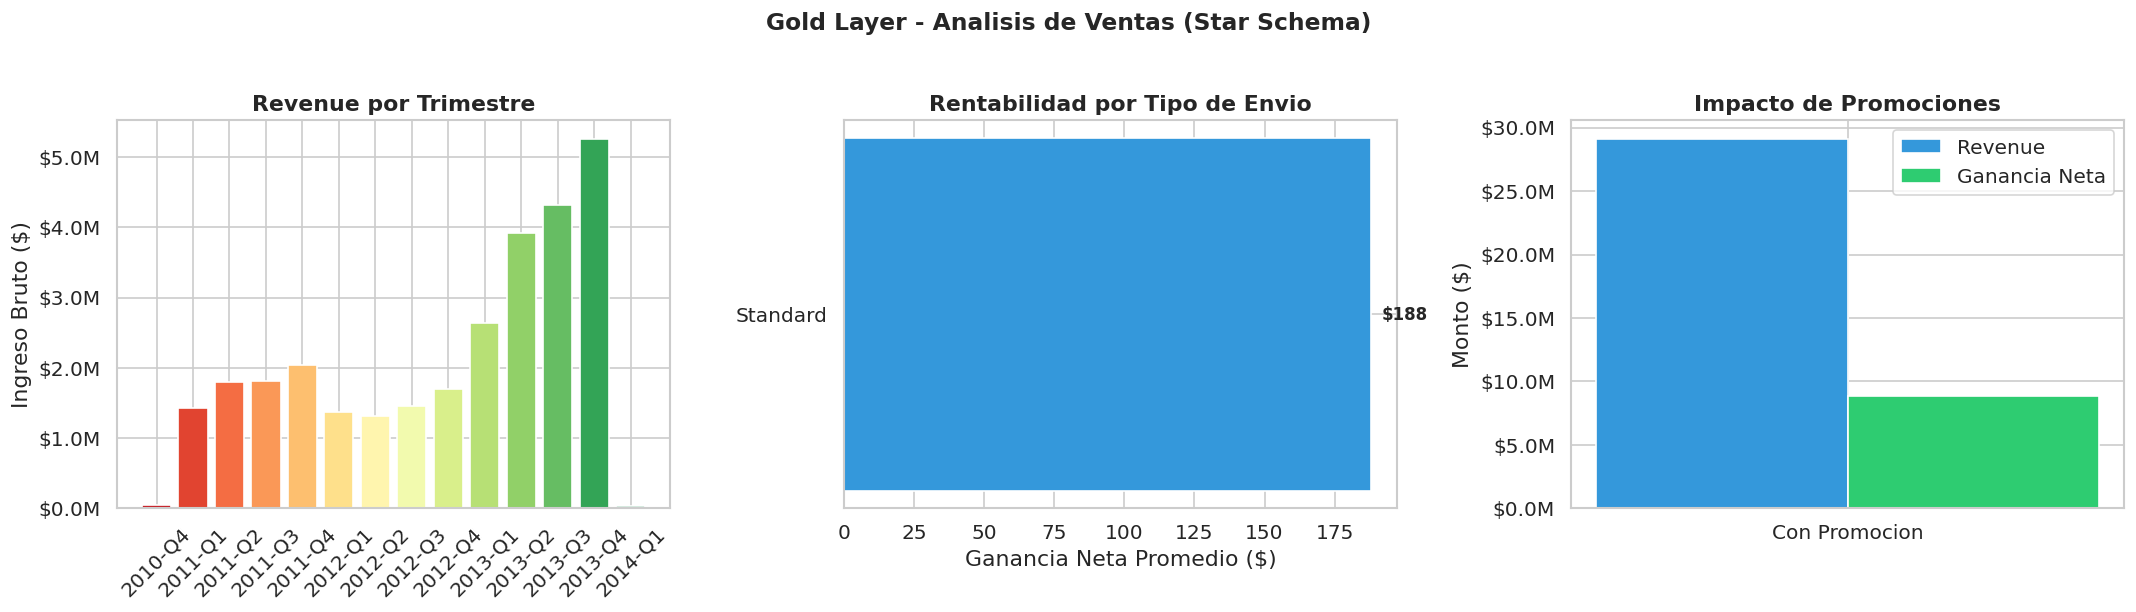

In [9]:
# ============================================================================
# GRAFICO: Analisis de fact_ventas - Metricas Gold
# ============================================================================
df_fv_pd = fact_ventas.select(
    'Year', 'Quarter', 'Period', 'Ingreso_Bruto',
    'Ganancia_Neta', 'Pct_Margen', 'Tipo_Envio', 'Tiene_Promocion'
).toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -- Panel 1: Revenue por Quarter y Year --
quarterly = df_fv_pd.groupby(['Year', 'Quarter'])['Ingreso_Bruto'].sum().reset_index()
quarterly['Label'] = quarterly['Year'].astype(str) + '-Q' + quarterly['Quarter'].astype(str)
colors_q = sns.color_palette('RdYlGn', len(quarterly))
axes[0].bar(quarterly['Label'], quarterly['Ingreso_Bruto'], color=colors_q, edgecolor='white')
axes[0].set_ylabel('Ingreso Bruto ($)')
axes[0].set_title('Revenue por Trimestre', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=45)

# -- Panel 2: Ganancia Neta promedio por tipo de envio --
envio_profit = df_fv_pd.groupby('Tipo_Envio')['Ganancia_Neta'].mean().sort_values()
colors_envio = {'Express': '#2ecc71', 'Standard': '#3498db', 'Delayed': '#e74c3c'}
axes[1].barh(envio_profit.index, envio_profit.values,
             color=[colors_envio.get(x, '#95a5a6') for x in envio_profit.index],
             edgecolor='white')
axes[1].set_xlabel('Ganancia Neta Promedio ($)')
axes[1].set_title('Rentabilidad por Tipo de Envio', fontweight='bold')
for bar, val in zip(axes[1].patches, envio_profit.values):
    axes[1].text(bar.get_width() + envio_profit.max() * 0.02,
                 bar.get_y() + bar.get_height() / 2,
                 f'${val:,.0f}', va='center', fontsize=10, fontweight='bold')

# -- Panel 3: Promocion vs No Promocion --
promo = df_fv_pd.groupby('Tiene_Promocion').agg(
    Revenue=('Ingreso_Bruto', 'sum'),
    Ganancia=('Ganancia_Neta', 'sum'),
    Ordenes=('Ingreso_Bruto', 'count')
).reset_index()
promo['Label'] = promo['Tiene_Promocion'].map({True: 'Con Promocion', False: 'Sin Promocion'})
x_pos = range(len(promo))
width = 0.35
bars1 = axes[2].bar([p - width/2 for p in x_pos], promo['Revenue'],
                    width, label='Revenue', color='#3498db', edgecolor='white')
bars2 = axes[2].bar([p + width/2 for p in x_pos], promo['Ganancia'],
                    width, label='Ganancia Neta', color='#2ecc71', edgecolor='white')
axes[2].set_xticks(list(x_pos))
axes[2].set_xticklabels(promo['Label'])
axes[2].set_ylabel('Monto ($)')
axes[2].set_title('Impacto de Promociones', fontweight='bold')
axes[2].legend()
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

plt.suptitle('Gold Layer - Analisis de Ventas (Star Schema)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Fact Table: Produccion Minera

**Fuente:** `eficiencia_minera` enriquecida con FK a dim_operador.

Tabla de hechos para el dominio minero con metricas de eficiencia por camion/proyecto.

In [10]:
# ============================================================================
# FACT_PRODUCCION_MINERA: Hechos de eficiencia minera
# ============================================================================
t0 = datetime.now()

fact_minera = (
    silver['eficiencia_minera']
    .withColumn('Total_Produccion', F.col('Total_Ore') + F.col('Total_Waste'))
    .withColumn('Clasificacion_Eficiencia',
        F.when(F.col('Efficiency_Pct') >= 95, 'Excelente')
         .when(F.col('Efficiency_Pct') >= 90, 'Buena')
         .when(F.col('Efficiency_Pct') >= 80, 'Aceptable')
         .otherwise('Deficiente'))
)

fact_minera.write.mode('overwrite').parquet(cos_path('gold', 'fact_produccion_minera'))
fact_m_count = fact_minera.count()
elapsed = (datetime.now() - t0).total_seconds()

print(f'fact_produccion_minera: {fact_m_count:,} filas | {elapsed:.1f}s')
fact_minera.show(truncate=False)

fact_produccion_minera: 7 filas | 4.0s


+-------+---------+------------------+------------------+-----+----------------+--------------+---------------+------------------+------------------------+
|TruckID|ProjectID|Total_Ore         |Total_Waste       |Trips|Avg_Ore_Per_Trip|Efficiency_Pct|Ore_Waste_Ratio|Total_Produccion  |Clasificacion_Eficiencia|
+-------+---------+------------------+------------------+-----+----------------+--------------+---------------+------------------+------------------------+
|346    |10       |16999.949999999997|1359.9959999999999|5    |3399.99         |92.59         |12.5           |18359.945999999996|Buena                   |
|346    |4        |10199.97          |815.9975999999999 |3    |3399.99         |92.59         |12.5           |11015.9676        |Buena                   |
|346    |6        |6799.98           |543.9984          |2    |3399.99         |92.59         |12.5           |7343.9784         |Buena                   |
|346    |9        |95199.72000000002 |7615.977600000004 |28   |3

---
## 9. KPI: Ventas Mensuales

Tabla de KPIs precalculados para dashboards, con metricas de crecimiento MoM (Month over Month).

In [11]:
# ============================================================================
# KPI_VENTAS_MENSUALES: Resumen con crecimiento MoM
# ============================================================================
t0 = datetime.now()

w_mom = Window.partitionBy('Categoria').orderBy('Year', 'Month')

kpi_ventas = (
    silver['resumen_ventas_mensuales']
    .withColumn('Periodo', F.concat(
        F.col('Year').cast('string'), F.lit('-'),
        F.lpad(F.col('Month').cast('string'), 2, '0')
    ))
    .withColumn('Revenue_Prev',
        F.lag('Ingreso_Bruto').over(w_mom))
    .withColumn('Crecimiento_MoM_Pct',
        F.when(F.col('Revenue_Prev').isNotNull() & (F.col('Revenue_Prev') > 0),
               F.round((F.col('Ingreso_Bruto') - F.col('Revenue_Prev')) / F.col('Revenue_Prev') * 100, 2))
         .otherwise(None))
    .withColumn('Ordenes_Prev',
        F.lag('Total_Ordenes').over(w_mom))
    .withColumn('Crecimiento_Ordenes_Pct',
        F.when(F.col('Ordenes_Prev').isNotNull() & (F.col('Ordenes_Prev') > 0),
               F.round((F.col('Total_Ordenes') - F.col('Ordenes_Prev')) / F.col('Ordenes_Prev') * 100, 2))
         .otherwise(None))
    .drop('Revenue_Prev', 'Ordenes_Prev')
)

kpi_ventas.write.mode('overwrite').parquet(cos_path('gold', 'kpi_ventas_mensuales'))
kpi_v_count = kpi_ventas.count()
elapsed = (datetime.now() - t0).total_seconds()

print(f'kpi_ventas_mensuales: {kpi_v_count:,} filas | {elapsed:.1f}s')
kpi_ventas.orderBy('Year', 'Month').select(
    'Periodo', 'Categoria', 'Total_Ordenes', 'Ingreso_Bruto',
    'Ganancia_Neta', 'Crecimiento_MoM_Pct'
).show(15, truncate=False)

kpi_ventas_mensuales: 65 filas | 5.0s
+-------+---------+-------------+-------------+-------------+-------------------+
|Periodo|Categoria|Total_Ordenes|Ingreso_Bruto|Ganancia_Neta|Crecimiento_MoM_Pct|
+-------+---------+-------------+-------------+-------------+-------------------+
|2010-12|Bicicleta|14           |43421.04     |13289.79     |NULL               |
|2011-01|Bicicleta|144          |469823.94    |139619.99    |982.02             |
|2011-02|Bicicleta|144          |466334.93    |139075.08    |-0.74              |
|2011-03|Bicicleta|150          |485198.69    |142131.64    |4.05               |
|2011-04|Bicicleta|157          |502073.88    |148816.57    |3.48               |
|2011-05|Bicicleta|174          |561681.51    |167053.36    |11.87              |
|2011-06|Bicicleta|230          |737839.87    |218652.34    |31.36              |
|2011-07|Bicicleta|188          |596746.6     |177662.9     |-19.12             |
|2011-08|Bicicleta|193          |614557.98    |180548.33    

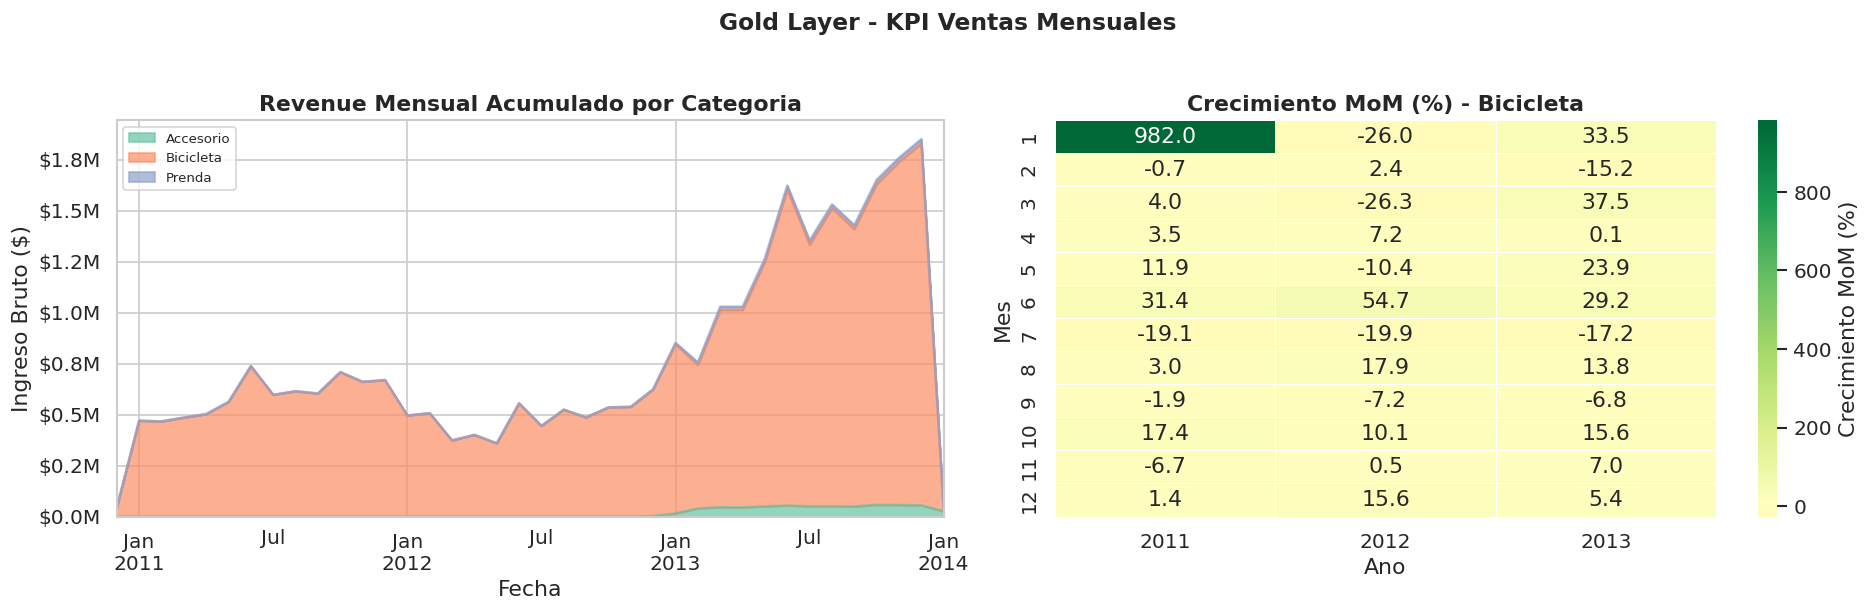

In [12]:
# ============================================================================
# GRAFICO: KPI Ventas Mensuales - Crecimiento y Tendencia
# ============================================================================
df_kpi_pd = kpi_ventas.toPandas()
df_kpi_pd['Fecha'] = pd.to_datetime(
    df_kpi_pd['Year'].astype(str) + '-' + df_kpi_pd['Month'].astype(str).str.zfill(2)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# -- Panel 1: Revenue mensual acumulado (stacked area) --
pivot_revenue = df_kpi_pd.pivot_table(
    values='Ingreso_Bruto', index='Fecha', columns='Categoria', aggfunc='sum'
).fillna(0).sort_index()
pivot_revenue.plot.area(ax=axes[0], alpha=0.7, stacked=True,
                        color=sns.color_palette('Set2', len(pivot_revenue.columns)))
axes[0].set_ylabel('Ingreso Bruto ($)')
axes[0].set_title('Revenue Mensual Acumulado por Categoria', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].legend(loc='upper left', fontsize=8)

# -- Panel 2: Heatmap crecimiento MoM --
bici_kpi = df_kpi_pd[df_kpi_pd['Categoria'] == df_kpi_pd['Categoria'].value_counts().idxmax()]
pivot_mom = bici_kpi.pivot_table(
    values='Crecimiento_MoM_Pct', index='Month', columns='Year', aggfunc='mean'
)
sns.heatmap(pivot_mom, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            ax=axes[1], linewidths=0.5, cbar_kws={'label': 'Crecimiento MoM (%)'})
axes[1].set_title(f'Crecimiento MoM (%) - {df_kpi_pd["Categoria"].value_counts().idxmax()}', fontweight='bold')
axes[1].set_ylabel('Mes')
axes[1].set_xlabel('Ano')

plt.suptitle('Gold Layer - KPI Ventas Mensuales',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 10. KPI: Mineria

Metricas consolidadas del dominio minero: produccion global, eficiencia y distribucion geografica.

In [13]:
# ============================================================================
# KPI_MINERIA: Metricas consolidadas del dominio minero
# ============================================================================
t0 = datetime.now()

kpi_mineria = (
    silver['produccion_por_pais']
    .withColumn('Pct_Produccion_Global',
        F.round(
            F.col('Total_Ore') / F.sum('Total_Ore').over(Window.partitionBy()) * 100,
        2))
    .withColumn('Waste_Ratio',
        F.round(F.col('Total_Waste') / F.col('Total_Ore') * 100, 2))
    .withColumn('_generated_at', F.current_timestamp())
    .orderBy(F.desc('Total_Ore'))
)

kpi_mineria.write.mode('overwrite').parquet(cos_path('gold', 'kpi_mineria'))
kpi_m_count = kpi_mineria.count()
elapsed = (datetime.now() - t0).total_seconds()

print(f'kpi_mineria: {kpi_m_count:,} filas | {elapsed:.1f}s')
kpi_mineria.show(truncate=False)

26/04/12 21:45:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 21:45:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 21:45:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 21:45:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


kpi_mineria: 6 filas | 4.4s


26/04/12 21:45:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 21:45:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 21:45:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 21:45:13 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 21:45:13 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+--------------+------------------+------------------+---------+------+-------------+--------------+----------------+---------------------+-----------+--------------------------+
|Country       |Total_Ore         |Total_Waste       |Operators|Trucks|Total_Records|Efficiency_Pct|Ore_Per_Operator|Pct_Produccion_Global|Waste_Ratio|_generated_at             |
+--------------+------------------+------------------+---------+------+-------------+--------------+----------------+---------------------+-----------+--------------------------+
|United States |8999859.530800585 |719988.7783000311 |3569     |116   |4907         |92.59         |2521.68         |31.78                |8.0        |2026-04-12 21:45:12.731453|
|Australia     |8852050.004400235 |708164.0202000273 |2155     |116   |4472         |92.59         |4107.68         |31.26                |8.0        |2026-04-12 21:45:12.731453|
|United Kingdom|3282842.6609001183|262627.41789999924|1032     |113   |1858         |92.59         |3181.

26/04/12 21:45:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 21:45:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


26/04/12 21:45:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 21:45:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


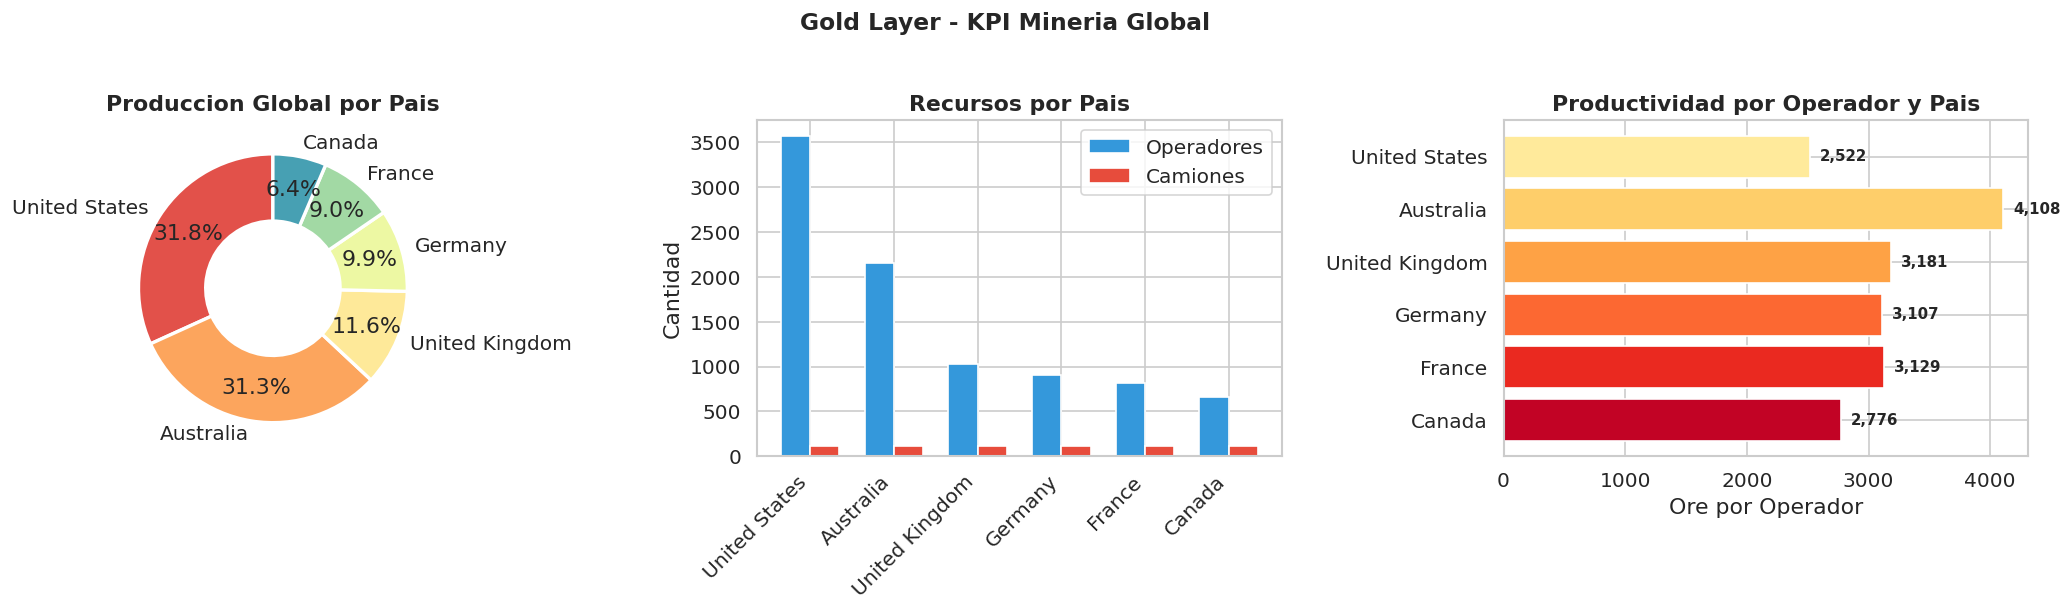

In [14]:
# ============================================================================
# GRAFICO: KPI Mineria - Vision global
# ============================================================================
df_kpi_min = kpi_mineria.toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -- Panel 1: Produccion por pais (donut chart) --
colors_pais = sns.color_palette('Spectral', len(df_kpi_min))
wedges, texts, autotexts = axes[0].pie(
    df_kpi_min['Total_Ore'], labels=df_kpi_min['Country'],
    autopct='%1.1f%%', colors=colors_pais,
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)
axes[0].set_title('Produccion Global por Pais', fontweight='bold')

# -- Panel 2: Operadores y Camiones por pais --
x_idx = range(len(df_kpi_min))
width = 0.35
axes[1].bar([i - width/2 for i in x_idx], df_kpi_min['Operators'],
            width, label='Operadores', color='#3498db', edgecolor='white')
axes[1].bar([i + width/2 for i in x_idx], df_kpi_min['Trucks'],
            width, label='Camiones', color='#e74c3c', edgecolor='white')
axes[1].set_xticks(list(x_idx))
axes[1].set_xticklabels(df_kpi_min['Country'], rotation=45, ha='right')
axes[1].set_ylabel('Cantidad')
axes[1].set_title('Recursos por Pais', fontweight='bold')
axes[1].legend()

# -- Panel 3: Ore per Operator por pais --
colors_opo = sns.color_palette('YlOrRd', len(df_kpi_min))
bars = axes[2].barh(df_kpi_min['Country'], df_kpi_min['Ore_Per_Operator'],
                    color=colors_opo, edgecolor='white')
axes[2].set_xlabel('Ore por Operador')
axes[2].set_title('Productividad por Operador y Pais', fontweight='bold')
axes[2].invert_yaxis()
for bar, val in zip(bars, df_kpi_min['Ore_Per_Operator']):
    axes[2].text(bar.get_width() + df_kpi_min['Ore_Per_Operator'].max() * 0.02,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:,.0f}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Gold Layer - KPI Mineria Global',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 11. Validacion de Integridad Referencial

Verificacion de que las Foreign Keys en las fact tables referencian registros existentes en las dimensiones.

In [15]:
# ============================================================================
# VALIDACION: Integridad referencial del Star Schema
# ============================================================================
print('=' * 60)
print('  VALIDACION DE INTEGRIDAD REFERENCIAL')
print('=' * 60)

# fact_ventas → dim_producto
fk_prod_null = fact_ventas.filter(F.col('producto_key').isNull()).count()
fk_prod_orphan = (
    fact_ventas.select('producto_key').distinct()
    .join(dim_producto.select('producto_key'), 'producto_key', 'left_anti')
    .count()
)
print(f'\nfact_ventas → dim_producto:')
print(f'   FKs nulas:    {fk_prod_null:,}')
print(f'   Huerfanas:    {fk_prod_orphan:,}')
print(f'   Estado:       {"OK" if fk_prod_null == 0 and fk_prod_orphan == 0 else "REVISAR"}')

# fact_ventas → dim_cliente
fk_cli_null = fact_ventas.filter(F.col('cliente_key').isNull()).count()
fk_cli_orphan = (
    fact_ventas.select('cliente_key').distinct()
    .join(dim_cliente.select('cliente_key'), 'cliente_key', 'left_anti')
    .count()
)
print(f'\nfact_ventas → dim_cliente:')
print(f'   FKs nulas:    {fk_cli_null:,}')
print(f'   Huerfanas:    {fk_cli_orphan:,}')
print(f'   Estado:       {"OK" if fk_cli_null == 0 and fk_cli_orphan == 0 else "REVISAR"}')

# fact_ventas → dim_tiempo
fk_tiempo_null = fact_ventas.filter(F.col('tiempo_key').isNull()).count()
fk_tiempo_orphan = (
    fact_ventas.select('tiempo_key').distinct()
    .join(dim_tiempo.select('tiempo_key'), 'tiempo_key', 'left_anti')
    .count()
)
print(f'\nfact_ventas → dim_tiempo:')
print(f'   FKs nulas:    {fk_tiempo_null:,}')
print(f'   Huerfanas:    {fk_tiempo_orphan:,}')
print(f'   Estado:       {"OK" if fk_tiempo_null == 0 and fk_tiempo_orphan == 0 else "REVISAR"}')

# Resumen de validacion
total_issues = fk_prod_null + fk_prod_orphan + fk_cli_null + fk_cli_orphan + fk_tiempo_null + fk_tiempo_orphan
print(f'\n{"=" * 60}')
print(f'  RESULTADO: {"TODAS LAS VALIDACIONES PASARON" if total_issues == 0 else f"{total_issues} ISSUES ENCONTRADOS"}')
print(f'{"=" * 60}')

  VALIDACION DE INTEGRIDAD REFERENCIAL

fact_ventas → dim_producto:
   FKs nulas:    0
   Huerfanas:    0
   Estado:       OK



fact_ventas → dim_cliente:
   FKs nulas:    0
   Huerfanas:    0
   Estado:       OK



fact_ventas → dim_tiempo:
   FKs nulas:    0
   Huerfanas:    0
   Estado:       OK

  RESULTADO: TODAS LAS VALIDACIONES PASARON


---
## 12. Persistencia Final y Resumen de Resultados

**Gold Layer completada.** Resumen consolidado de todas las tablas generadas.

| # | Tabla Gold | Tipo | Descripcion |
|---|-----------|------|-------------|
| 1 | `dim_producto` | Dimension | Catalogo con clasificaciones de negocio |
| 2 | `dim_cliente` | Dimension | Segmentacion RFM + LTV + rangos |
| 3 | `dim_tiempo` | Dimension | Calendario completo |
| 4 | `dim_operador` | Dimension | Operadores con niveles de eficiencia |
| 5 | `fact_ventas` | Fact | Hechos de ventas con FKs dimensionales |
| 6 | `fact_produccion_minera` | Fact | Hechos de mineria por camion/proyecto |
| 7 | `kpi_ventas_mensuales` | KPI | Metricas mensuales con crecimiento MoM |
| 8 | `kpi_mineria` | KPI | Metricas globales de mineria por pais |

,Tabla,Tipo,Filas,Columnas,Estado
0,dim_producto,Dimension,319,12,OK
1,dim_cliente,Dimension,"17,555",15,OK
2,dim_tiempo,Dimension,"1,127",12,OK
3,dim_operador,Dimension,"9,132",14,OK
4,fact_ventas,Fact,"47,263",20,OK
5,fact_produccion_minera,Fact,7,10,OK
6,kpi_ventas_mensuales,KPI,65,13,OK
7,kpi_mineria,KPI,6,11,OK


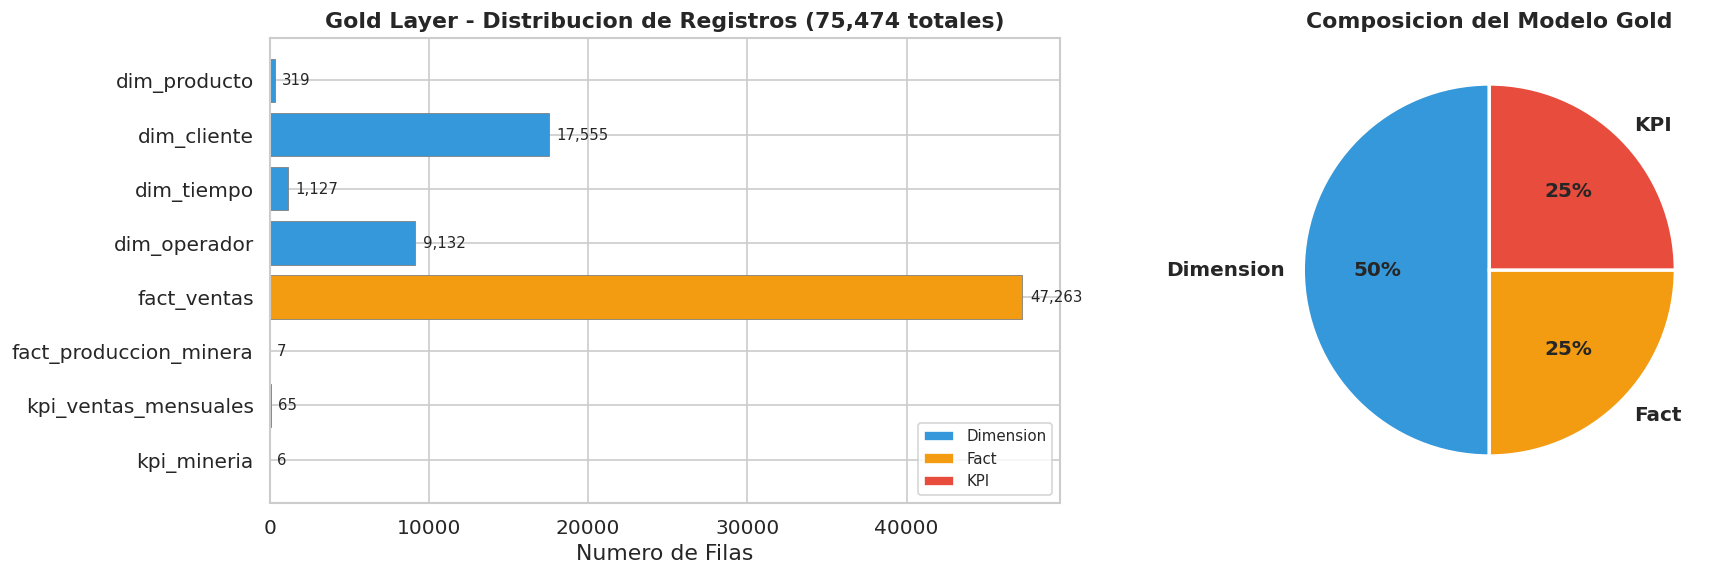


------------------------------------------------------------
  GOLD LAYER COMPLETADA
  Tablas generadas:   8
    - Dimensiones:    4
    - Facts:          2
    - KPIs:           2
  Total registros:    75,474
------------------------------------------------------------

SparkSession finalizada.


In [16]:
# ============================================================================
# RESUMEN FINAL: Inventario de tablas Gold producidas
# ============================================================================
gold_tables = {
    'dim_producto': dim_producto,
    'dim_cliente': dim_cliente,
    'dim_tiempo': dim_tiempo,
    'dim_operador': dim_operador,
    'fact_ventas': fact_ventas,
    'fact_produccion_minera': fact_minera,
    'kpi_ventas_mensuales': kpi_ventas,
    'kpi_mineria': kpi_mineria,
}

summary_rows = []
total_rows = 0
for name, df in gold_tables.items():
    cnt = df.count()
    cols = len(df.columns)
    total_rows += cnt
    tipo = 'Dimension' if name.startswith('dim_') else ('KPI' if name.startswith('kpi_') else 'Fact')
    summary_rows.append({
        'Tabla': name,
        'Tipo': tipo,
        'Filas': f'{cnt:,}',
        'Columnas': cols,
        'Estado': 'OK'
    })

summary_df = pd.DataFrame(summary_rows)
styled = (
    summary_df.style
    .set_caption(f'Gold Layer - {len(gold_tables)} tablas | {total_rows:,} filas totales')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#1a5276')]},
        {'selector': 'th', 'props': [('background-color', '#f39c12'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '6px 12px')]},
    ])
    .apply(lambda x: ['background-color: #d5f5e3' if v == 'OK' else '' for v in x], subset=['Estado'])
    .apply(lambda x: [
        'background-color: #ebf5fb' if v == 'Dimension'
        else 'background-color: #fef9e7' if v == 'Fact'
        else 'background-color: #f9ebea' if v == 'KPI'
        else ''
        for v in x
    ], subset=['Tipo'])
)
display(styled)

# --- Grafico resumen ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Barras por tabla
names = [r['Tabla'] for r in summary_rows]
counts = [int(r['Filas'].replace(',', '')) for r in summary_rows]
tipos = [r['Tipo'] for r in summary_rows]
color_map = {'Dimension': '#3498db', 'Fact': '#f39c12', 'KPI': '#e74c3c'}
bar_colors = [color_map.get(t, '#95a5a6') for t in tipos]
bars = axes[0].barh(names, counts, color=bar_colors, edgecolor='gray', linewidth=0.5)
axes[0].set_xlabel('Numero de Filas')
axes[0].set_title(f'Gold Layer - Distribucion de Registros ({total_rows:,} totales)', fontweight='bold')
axes[0].invert_yaxis()
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_width() + max(counts) * 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{cnt:,}', va='center', fontsize=9)

# Panel 2: Pie por tipo de tabla
tipo_summary = summary_df.groupby('Tipo').size()
axes[1].pie(tipo_summary.values, labels=tipo_summary.index, autopct='%1.0f%%',
            colors=[color_map.get(t, '#95a5a6') for t in tipo_summary.index],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2),
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Composicion del Modelo Gold', fontweight='bold')

# Leyenda personalizada
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[t], label=t) for t in color_map]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

separator = '-' * 60
print(f'\n{separator}')
print(f'  GOLD LAYER COMPLETADA')
print(f'  Tablas generadas:   {len(gold_tables)}')
print(f'    - Dimensiones:    {sum(1 for r in summary_rows if r["Tipo"] == "Dimension")}')
print(f'    - Facts:          {sum(1 for r in summary_rows if r["Tipo"] == "Fact")}')
print(f'    - KPIs:           {sum(1 for r in summary_rows if r["Tipo"] == "KPI")}')
print(f'  Total registros:    {total_rows:,}')
print(f'{separator}')

# Liberar recursos
spark.stop()
print('\nSparkSession finalizada.')